# Classification Evaluation

この notebook では、各実験の **最良モデル** を基準に評価します。

方針:
- 比較できるものだけ比較する
- `experiment_summary.json` を持つ実験を読む
- 全実験で共通なのは `validation / test accuracy` を見る
- `grid / optuna` がある実験だけ tuning 推移を見る
- `history.csv` がある実験だけ学習曲線を見る
- `predictions.csv` がある実験だけクラス別成績や誤分類を見る
- `confidence` の意味が揃っていない実験は、confidence 比較から外す

前提:
- `train.py --config ...` または zero-shot / few-shot スクリプトを実行済み
- 実験ディレクトリに `experiment_summary.json` と `best_test_results/` がある
- 比較の基準は基本的に **最良モデルの結果** に揃える


In [273]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")


## 1. 実験一覧を読む

ここでは `checkpoints/classification/*/*/experiment_summary.json` を探します。

この summary には、その実験で最終的に選ばれた best model の情報が入っています。


In [274]:
checkpoints_root = Path("/workspace/checkpoints/classification")
experiment_dirs = sorted(
    experiment_dir
    for experiment_dir in checkpoints_root.glob("*/*")
    if (experiment_dir / "experiment_summary.json").exists()
)

if not experiment_dirs:
    raise FileNotFoundError(
        "experiment_summary.json を持つ実験が見つかりません。先に train.py や zero-shot / few-shot スクリプトを実行してください。"
    )

experiment_dirs


[PosixPath('/workspace/checkpoints/classification/convnext_v2/oxford_pet'),
 PosixPath('/workspace/checkpoints/classification/convnext_v2/oxford_pet_smoke'),
 PosixPath('/workspace/checkpoints/classification/eva02/oxford_pet'),
 PosixPath('/workspace/checkpoints/classification/eva02/oxford_pet_smoke'),
 PosixPath('/workspace/checkpoints/classification/florence2/oxford_pet'),
 PosixPath('/workspace/checkpoints/classification/florence2/oxford_pet_fewshot'),
 PosixPath('/workspace/checkpoints/classification/florence2/oxford_pet_fewshot_quick'),
 PosixPath('/workspace/checkpoints/classification/florence2/oxford_pet_quick'),
 PosixPath('/workspace/checkpoints/classification/florence2/oxford_pet_zeroshot'),
 PosixPath('/workspace/checkpoints/classification/florence2/oxford_pet_zeroshot_quick'),
 PosixPath('/workspace/checkpoints/classification/florence2/oxford_pet_zeroshot_smoke'),
 PosixPath('/workspace/checkpoints/classification/siglip2/oxford_pet'),
 PosixPath('/workspace/checkpoints/clas

In [275]:
def load_experiment_artifacts(experiment_dir: Path) -> dict[str, object]:
    experiment_summary = json.loads((experiment_dir / "experiment_summary.json").read_text())
    best_checkpoint_path = Path(experiment_summary["best_checkpoint_path"])
    best_run_dir = best_checkpoint_path.parent

    history_df = pd.read_csv(best_run_dir / "history.csv") if (best_run_dir / "history.csv").exists() else None
    best_test_dir = experiment_dir / "best_test_results"
    predictions_df = pd.read_csv(best_test_dir / "predictions.csv") if (best_test_dir / "predictions.csv").exists() else None
    report_df = pd.read_csv(best_test_dir / "classification_report.csv", index_col=0) if (best_test_dir / "classification_report.csv").exists() else None
    test_summary = json.loads((best_test_dir / "summary.json").read_text()) if (best_test_dir / "summary.json").exists() else None

    grid_results_df = pd.read_csv(experiment_dir / "grid" / "tuning_results.csv") if (experiment_dir / "grid" / "tuning_results.csv").exists() else None
    optuna_results_df = pd.read_csv(experiment_dir / "optuna" / "optuna_results.csv") if (experiment_dir / "optuna" / "optuna_results.csv").exists() else None

    comparable_confidence = False
    if predictions_df is not None and "confidence" in predictions_df.columns:
        confidence_series = predictions_df["confidence"].dropna()
        comparable_confidence = confidence_series.nunique() > 1

    return {
        "model_name": experiment_dir.parent.name,
        "experiment_name": experiment_dir.name,
        "experiment_dir": experiment_dir,
        "experiment_summary": experiment_summary,
        "mode": experiment_summary.get("mode", "unknown"),
        "best_run_dir": best_run_dir,
        "history_df": history_df,
        "predictions_df": predictions_df,
        "report_df": report_df,
        "test_summary": test_summary,
        "grid_results_df": grid_results_df,
        "optuna_results_df": optuna_results_df,
        "has_tuning": grid_results_df is not None or optuna_results_df is not None,
        "has_history": history_df is not None,
        "has_predictions": predictions_df is not None,
        "has_report": report_df is not None,
        "comparable_confidence": comparable_confidence,
    }

artifacts = [load_experiment_artifacts(experiment_dir) for experiment_dir in experiment_dirs]
len(artifacts)


17

## 2. 全実験で共通な主要指標を比較する

ここでは、zero-shot / few-shot / supervised をまとめて見られる軸だけ比較します。

見るもの:
- mode
- best validation accuracy
- test accuracy
- best model の出どころ (`train`, `optuna`, `zeroshot`, `fewshot` など)
- artifact の有無


In [276]:
summary_rows = []
for artifact in artifacts:
    experiment_summary = artifact["experiment_summary"]
    test_summary = artifact["test_summary"] or {}
    summary_rows.append(
        {
            "model_name": artifact["model_name"],
            "experiment_name": artifact["experiment_name"],
            "mode": artifact["mode"],
            "best_source": experiment_summary.get("best_source"),
            "best_run_name": experiment_summary.get("best_run_name"),
            "best_valid_accuracy": experiment_summary.get("best_valid_accuracy"),
            "test_accuracy": test_summary.get("accuracy"),
            "has_tuning": artifact["has_tuning"],
            "has_history": artifact["has_history"],
            "has_predictions": artifact["has_predictions"],
            "comparable_confidence": artifact["comparable_confidence"],
            "best_checkpoint_path": experiment_summary.get("best_checkpoint_path"),
        }
    )

experiment_summary_df = pd.DataFrame(summary_rows).sort_values(
    ["test_accuracy", "best_valid_accuracy"], ascending=False
).reset_index(drop=True)
experiment_summary_df


,model_name,experiment_name,mode,best_source,best_run_name,best_valid_accuracy,test_accuracy,has_tuning,has_history,has_predictions,comparable_confidence,best_checkpoint_path
0,eva02,oxford_pet,full,optuna,trial_016,0.964674,0.941946,True,True,True,True,/workspace/checkpoints/classification/eva02/ox...
1,convnext_v2,oxford_pet,full,optuna,trial_023,0.964674,0.926410,True,True,True,True,/workspace/checkpoints/classification/convnext...
2,siglip2,oxford_pet,full,optuna,trial_023,0.953804,0.914963,True,True,True,True,/workspace/checkpoints/classification/siglip2/...
3,convnext_v2,oxford_pet_smoke,none,train,train,0.881793,0.850368,False,True,True,True,/workspace/checkpoints/classification/convnext...
4,siglip2,oxford_pet_fewshot,fewshot,fewshot,fewshot,0.769022,0.738621,False,True,True,True,/workspace/checkpoints/classification/siglip2/...
5,siglip2,oxford_pet_zeroshot_smoke,zeroshot,zeroshot,zeroshot,0.690217,0.714364,False,False,True,True,/workspace/checkpoints/classification/siglip2/...
6,siglip2,oxford_pet_zeroshot,zeroshot,zeroshot,zeroshot,0.688859,0.714364,False,False,True,True,/workspace/checkpoints/classification/siglip2/...
7,eva02,oxford_pet_smoke,none,train,train,0.559783,0.566912,False,True,True,True,/workspace/checkpoints/classification/eva02/ox...
8,florence2,oxford_pet_zeroshot,zeroshot,zeroshot,zeroshot,0.252717,0.256746,False,False,True,False,/workspace/checkpoints/classification/florence...
9,florence2,oxford_pet_zeroshot_smoke,zeroshot,zeroshot,zeroshot,0.252717,0.256746,False,False,True,False,/workspace/checkpoints/classification/florence...


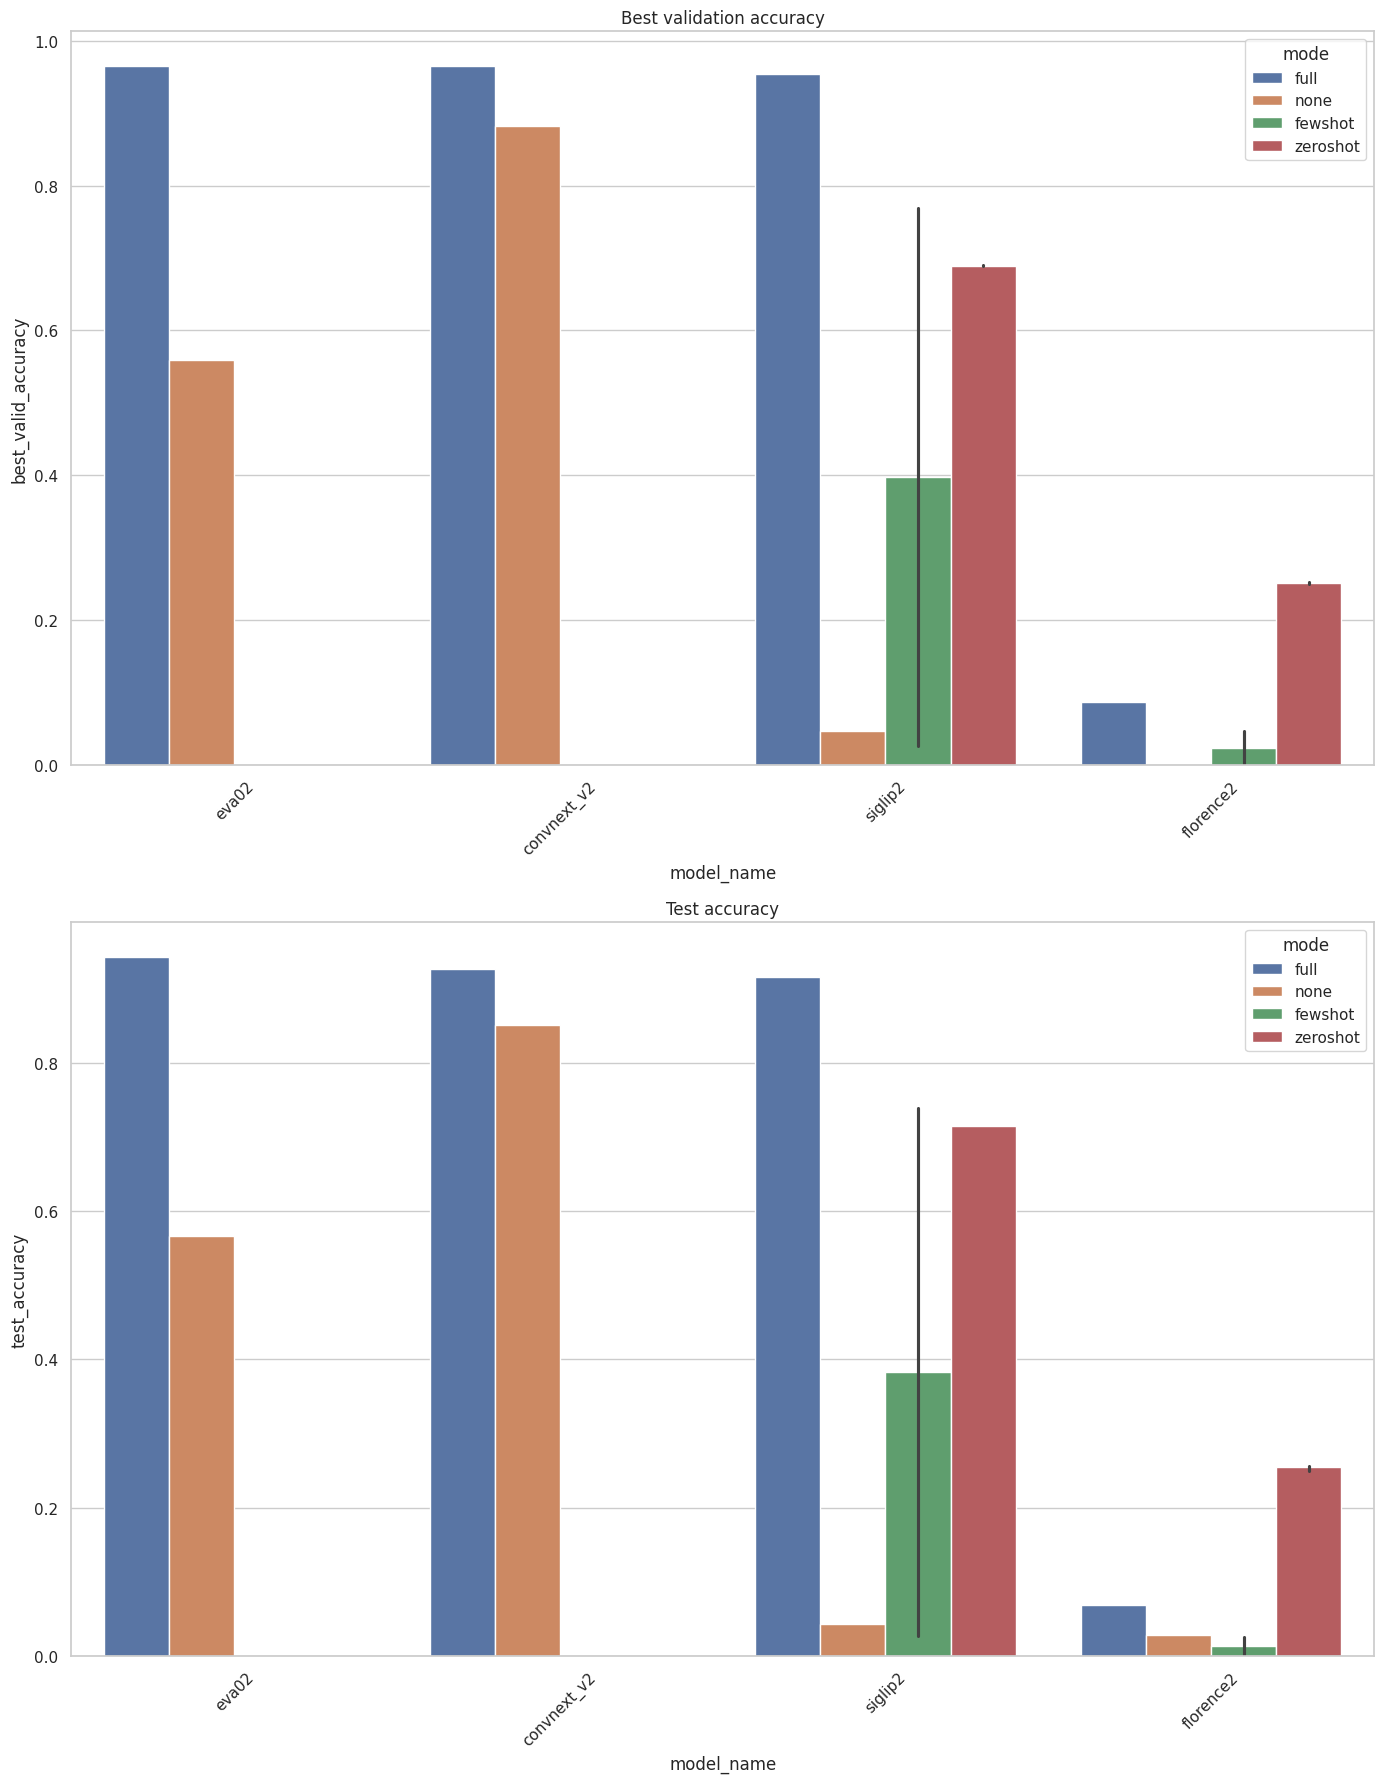

In [292]:
fig, axes = plt.subplots(2, 1, figsize=(14, 18))

sns.barplot(data=experiment_summary_df, x="model_name", y="best_valid_accuracy", hue="mode", ax=axes[0])
axes[0].set_title("Best validation accuracy")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=experiment_summary_df, x="model_name", y="test_accuracy", hue="mode", ax=axes[1])
axes[1].set_title("Test accuracy")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 3. tuning がある実験だけを見る

ここでは `grid` / `optuna` を持つ実験だけを対象にします。

つまり supervised の tuning 実験は入りますが、zero-shot は通常ここに入りません。


In [278]:
tuning_frames = []
for artifact in artifacts:
    grid_df = artifact["grid_results_df"]
    optuna_df = artifact["optuna_results_df"]
    grid_count = len(grid_df) if grid_df is not None else 0

    if grid_df is not None:
        temp_df = grid_df.copy()
        temp_df["model_name"] = artifact["model_name"]
        temp_df["experiment_name"] = artifact["experiment_name"]
        temp_df["mode"] = artifact["mode"]
        temp_df["search_method"] = "grid"
        temp_df["trial_order"] = range(1, len(temp_df) + 1)
        temp_df["global_trial_order"] = temp_df["trial_order"]
        temp_df["model_experiment"] = temp_df["model_name"] + "/" + temp_df["experiment_name"]
        tuning_frames.append(temp_df)

    if optuna_df is not None:
        temp_df = optuna_df.copy()
        temp_df["model_name"] = artifact["model_name"]
        temp_df["experiment_name"] = artifact["experiment_name"]
        temp_df["mode"] = artifact["mode"]
        temp_df["search_method"] = "optuna"
        temp_df["trial_order"] = range(1, len(temp_df) + 1)
        temp_df["global_trial_order"] = temp_df["trial_order"] + grid_count
        temp_df["model_experiment"] = temp_df["model_name"] + "/" + temp_df["experiment_name"]
        tuning_frames.append(temp_df)

tuning_all_df = pd.concat(tuning_frames, ignore_index=True) if tuning_frames else pd.DataFrame()
tuning_all_df.head()


,trial_name,output_dir,best_checkpoint_path,best_valid_accuracy,learning_rate,weight_decay,batch_size,image_size,model_name,experiment_name,mode,search_method,trial_order,global_trial_order,model_experiment
0,trial_001,/workspace/checkpoints/classification/convnext...,/workspace/checkpoints/classification/convnext...,0.942935,0.000100,0.000100,32,224,convnext_v2,oxford_pet,full,grid,1,1,convnext_v2/oxford_pet
1,trial_002,/workspace/checkpoints/classification/convnext...,/workspace/checkpoints/classification/convnext...,0.936141,0.000100,0.001000,32,224,convnext_v2,oxford_pet,full,grid,2,2,convnext_v2/oxford_pet
2,trial_003,/workspace/checkpoints/classification/convnext...,/workspace/checkpoints/classification/convnext...,0.044837,0.001000,0.000100,32,224,convnext_v2,oxford_pet,full,grid,3,3,convnext_v2/oxford_pet
3,trial_004,/workspace/checkpoints/classification/convnext...,/workspace/checkpoints/classification/convnext...,0.027174,0.001000,0.001000,32,224,convnext_v2,oxford_pet,full,grid,4,4,convnext_v2/oxford_pet
4,trial_023,/workspace/checkpoints/classification/convnext...,/workspace/checkpoints/classification/convnext...,0.964674,0.000073,0.000271,64,256,convnext_v2,oxford_pet,full,optuna,1,5,convnext_v2/oxford_pet


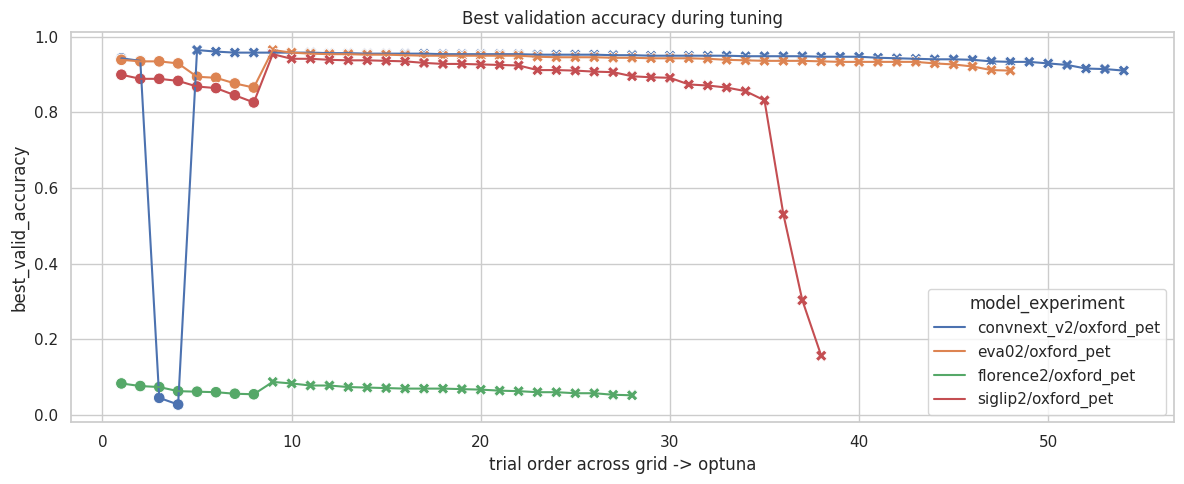

In [279]:
if len(tuning_all_df) == 0:
    print("tuning 結果はありません。")
else:
    plt.figure(figsize=(12, 5))
    sns.lineplot(
        data=tuning_all_df,
        x="global_trial_order",
        y="best_valid_accuracy",
        hue="model_experiment",
        estimator=None,
    )
    sns.scatterplot(
        data=tuning_all_df,
        x="global_trial_order",
        y="best_valid_accuracy",
        hue="model_experiment",
        style="search_method",
        markers=True,
        legend=False,
        s=70,
    )
    plt.title("Best validation accuracy during tuning")
    plt.xlabel("trial order across grid -> optuna")
    plt.ylabel("best_valid_accuracy")
    plt.tight_layout()
    plt.show()


In [280]:
if len(tuning_all_df) > 0:
    tuning_summary_df = tuning_all_df[[
        "model_name",
        "experiment_name",
        "search_method",
        "trial_name",
        "best_valid_accuracy",
        "learning_rate",
        "weight_decay",
        "batch_size",
        "image_size",
    ]].sort_values("best_valid_accuracy", ascending=False).reset_index(drop=True)
    tuning_summary_df


## 4. history がある実験だけ学習曲線を見る

学習曲線は `history.csv` を持つ実験だけ表示します。

つまり:
- supervised
- few-shot

は入りますが、zero-shot は通常入りません。


In [281]:
history_frames = []
for artifact in artifacts:
    history_df = artifact["history_df"]
    if history_df is None:
        continue
    temp_df = history_df.copy()
    temp_df["model_name"] = artifact["model_name"]
    temp_df["experiment_name"] = artifact["experiment_name"]
    temp_df["mode"] = artifact["mode"]
    temp_df["model_experiment"] = temp_df["model_name"] + "/" + temp_df["experiment_name"]
    history_frames.append(temp_df)

best_history_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()
best_history_df.head()


,epoch,train_loss,train_accuracy,valid_loss,valid_accuracy,model_name,experiment_name,mode,model_experiment
0,1,1.650986,0.682405,0.477042,0.937500,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet
1,2,0.252094,0.954823,0.225383,0.941576,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet
2,3,0.096986,0.985394,0.175044,0.952446,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet
3,4,0.062848,0.986753,0.161486,0.964674,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet
4,5,0.031392,0.996943,0.161462,0.952446,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet


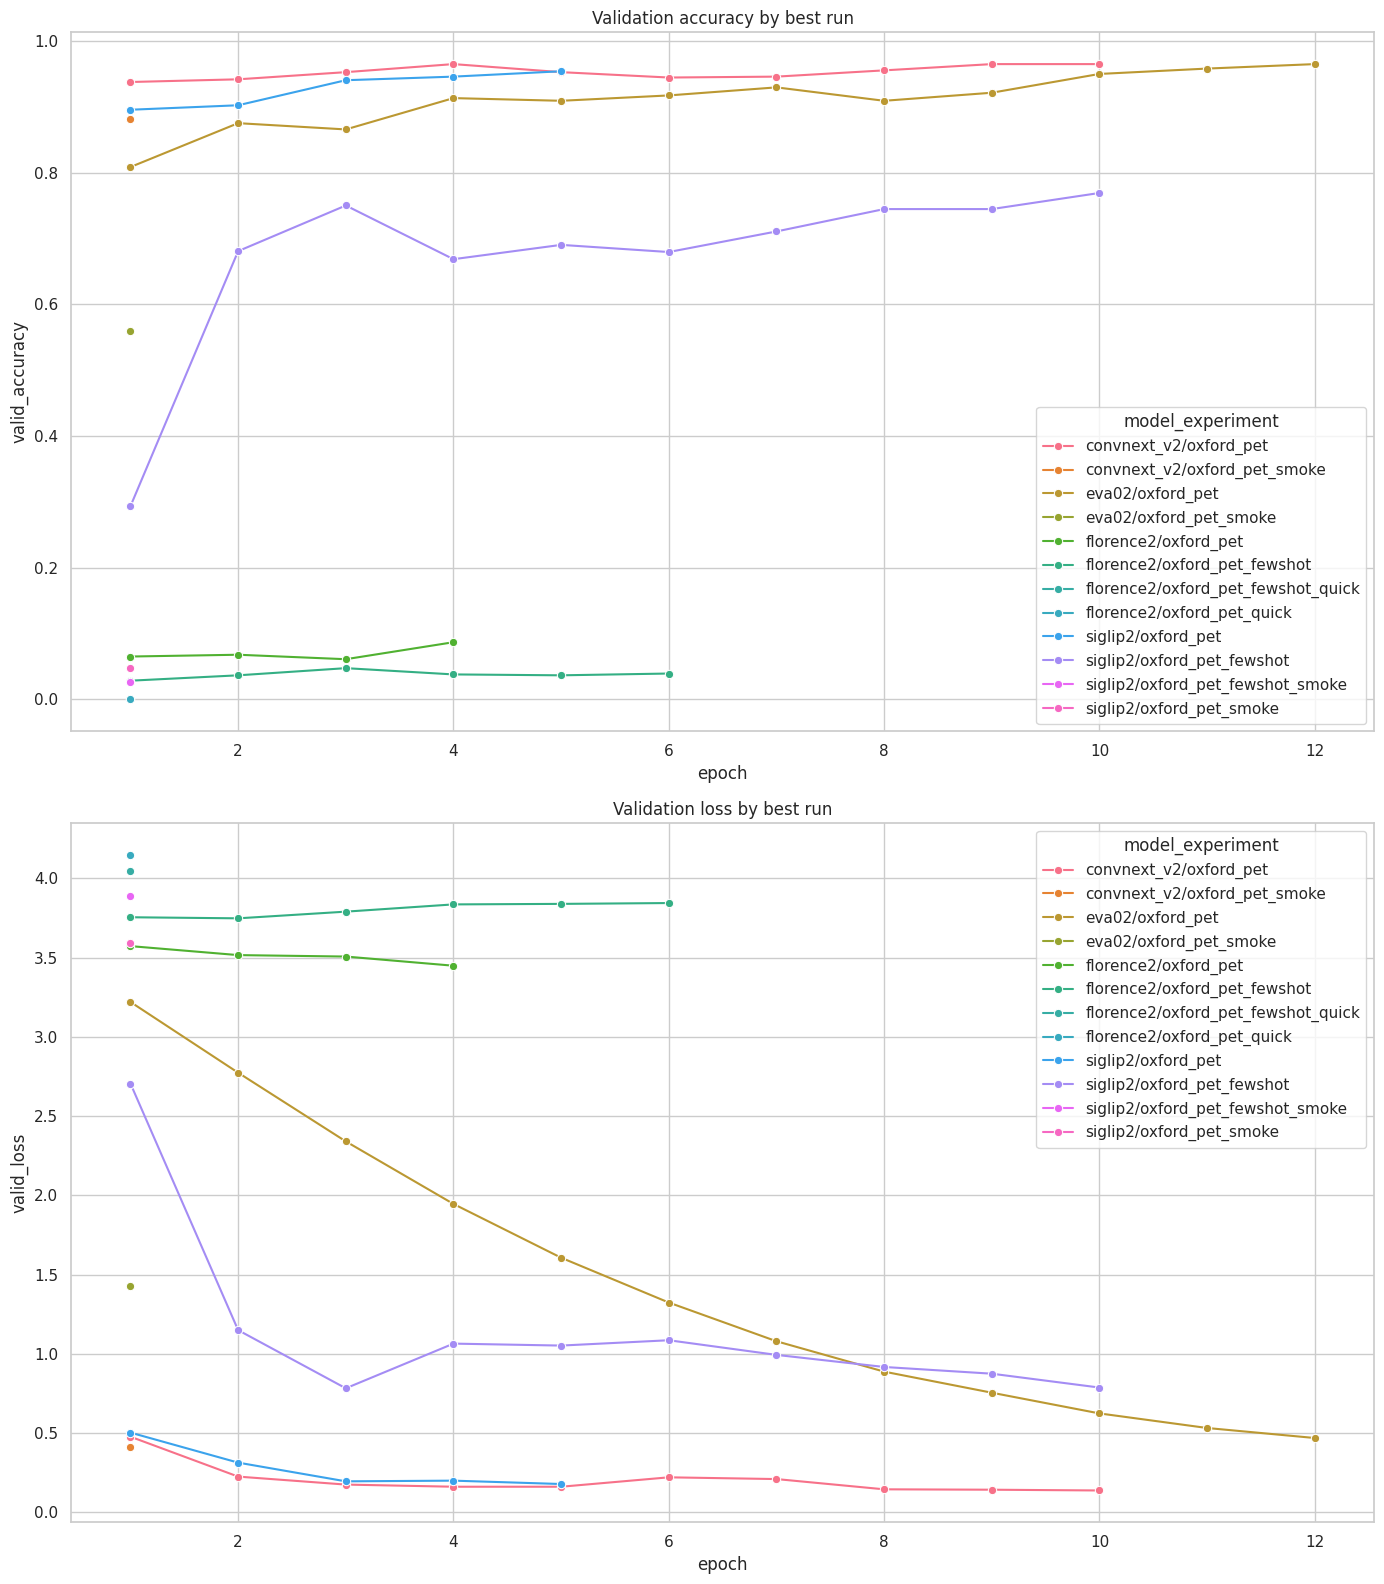

In [293]:
if len(best_history_df) == 0:
    print("history.csv がありません。")
else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 16))
    sns.lineplot(data=best_history_df, x="epoch", y="valid_accuracy", hue="model_experiment", marker="o", ax=axes[0])
    axes[0].set_title("Validation accuracy by best run")

    sns.lineplot(data=best_history_df, x="epoch", y="valid_loss", hue="model_experiment", marker="o", ax=axes[1])
    axes[1].set_title("Validation loss by best run")

    plt.tight_layout()
    plt.show()


## 5. predictions がある実験だけクラス別成績を見る

ここから先は `predictions.csv` と `classification_report.csv` を持つ実験だけを対象にします。


In [283]:
report_frames = []
for artifact in artifacts:
    report_df = artifact["report_df"]
    if report_df is None:
        continue
    temp_df = report_df.copy()
    temp_df["class_name"] = temp_df.index
    temp_df = temp_df[~temp_df["class_name"].isin(["accuracy", "macro avg", "weighted avg"])].copy()
    temp_df["model_name"] = artifact["model_name"]
    temp_df["experiment_name"] = artifact["experiment_name"]
    temp_df["mode"] = artifact["mode"]
    temp_df["model_experiment"] = temp_df["model_name"] + "/" + temp_df["experiment_name"]
    report_frames.append(temp_df)

best_report_df = pd.concat(report_frames, ignore_index=True) if report_frames else pd.DataFrame()
best_report_df.head()


,precision,recall,f1-score,support,class_name,model_name,experiment_name,mode,model_experiment
0,0.989362,0.94898,0.968750,98.0,Abyssinian,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet
1,0.857143,0.84000,0.848485,100.0,american_bulldog,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet
2,0.833333,0.60000,0.697674,100.0,american_pit_bull_terrier,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet
3,0.950000,0.95000,0.950000,100.0,basset_hound,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet
4,0.948454,0.92000,0.934010,100.0,beagle,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet


In [284]:
if len(best_report_df) > 0:
    report_summary_df = (
        best_report_df.groupby(["model_name", "experiment_name", "mode"])[["precision", "recall", "f1-score"]]
        .mean()
        .reset_index()
        .sort_values("f1-score", ascending=False)
    )
    report_summary_df


## 6. confidence が比較可能な実験だけ分布を見る

confidence の定義が揃っていない実験はここから外します。

例えば生成ベース zero-shot のように confidence を 1.0 固定で持っている実験は、ここでは比較しません。


In [285]:
prediction_frames = []
for artifact in artifacts:
    predictions_df = artifact["predictions_df"]
    if predictions_df is None or not artifact["comparable_confidence"]:
        continue
    temp_df = predictions_df.copy()
    temp_df["model_name"] = artifact["model_name"]
    temp_df["experiment_name"] = artifact["experiment_name"]
    temp_df["mode"] = artifact["mode"]
    temp_df["model_experiment"] = temp_df["model_name"] + "/" + temp_df["experiment_name"]
    temp_df["is_correct"] = temp_df["label"] == temp_df["prediction"]
    prediction_frames.append(temp_df)

best_predictions_df = pd.concat(prediction_frames, ignore_index=True) if prediction_frames else pd.DataFrame()
best_predictions_df.head()


,image_path,image_stem,breed_name,label,prediction,confidence,model_name,experiment_name,mode,model_experiment,is_correct
0,/workspace/data/oxford_iiit_pet/images/Abyssin...,Abyssinian_201,Abyssinian,0,0,0.828666,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet,True
1,/workspace/data/oxford_iiit_pet/images/Abyssin...,Abyssinian_202,Abyssinian,0,0,0.955058,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet,True
2,/workspace/data/oxford_iiit_pet/images/Abyssin...,Abyssinian_204,Abyssinian,0,0,0.538781,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet,True
3,/workspace/data/oxford_iiit_pet/images/Abyssin...,Abyssinian_205,Abyssinian,0,0,0.888624,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet,True
4,/workspace/data/oxford_iiit_pet/images/Abyssin...,Abyssinian_206,Abyssinian,0,5,0.629127,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet,False


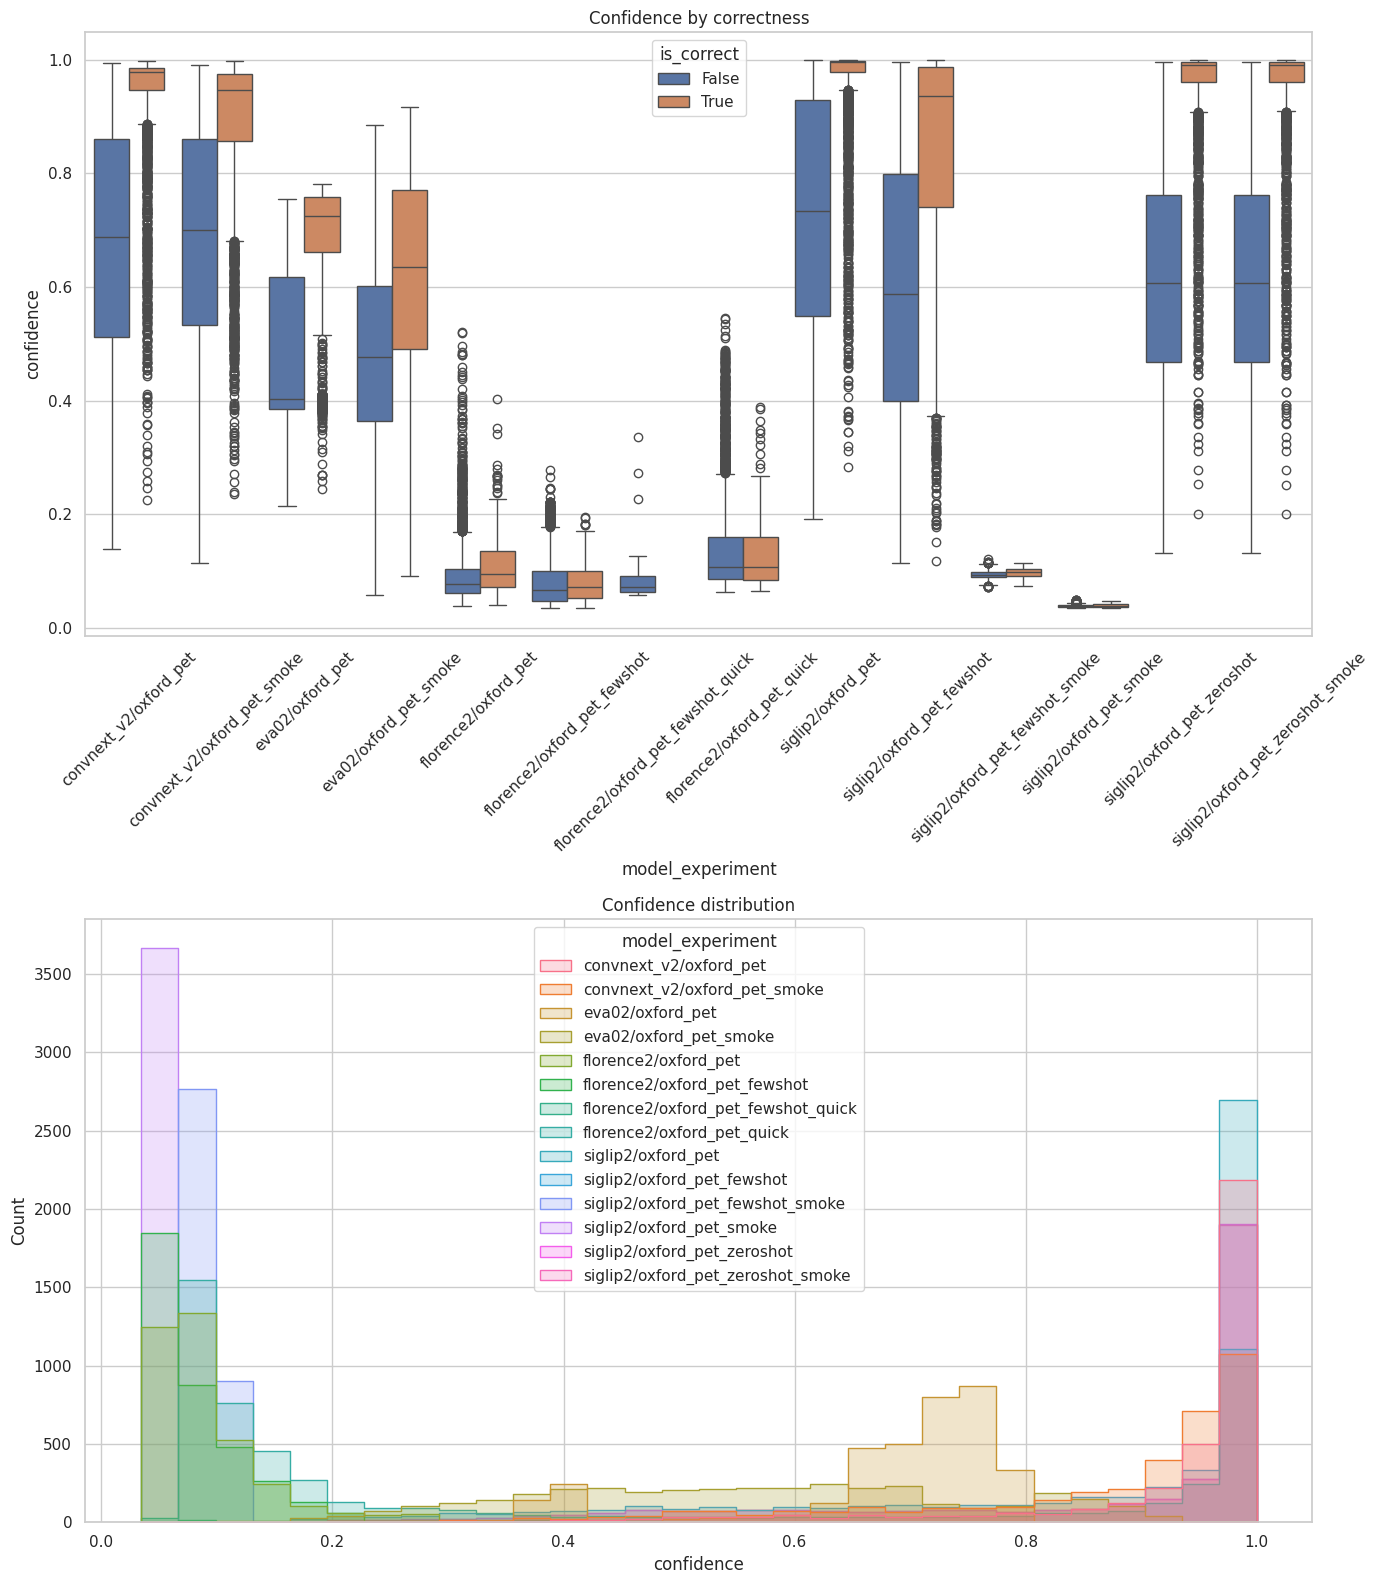

In [294]:
if len(best_predictions_df) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 16))
    sns.boxplot(data=best_predictions_df, x="model_experiment", y="confidence", hue="is_correct", ax=axes[0])
    axes[0].set_title("Confidence by correctness")
    axes[0].tick_params(axis="x", rotation=45)

    sns.histplot(data=best_predictions_df, x="confidence", hue="model_experiment", bins=30, element="step", ax=axes[1])
    axes[1].set_title("Confidence distribution")

    plt.tight_layout()
    plt.show()
else:
    print("比較可能な confidence を持つ実験がありません。")


## 7. 誤分類例を見る

誤分類例は `predictions.csv` がある実験なら見られます。

confidence の比較とは違って、ここは zero-shot / few-shot / supervised を問わず使えます。


In [287]:
mistake_frames = []
for artifact in artifacts:
    predictions_df = artifact["predictions_df"]
    if predictions_df is None:
        continue
    temp_df = predictions_df.copy()
    temp_df["model_name"] = artifact["model_name"]
    temp_df["experiment_name"] = artifact["experiment_name"]
    temp_df["mode"] = artifact["mode"]
    temp_df["model_experiment"] = temp_df["model_name"] + "/" + temp_df["experiment_name"]
    temp_df["is_correct"] = temp_df["label"] == temp_df["prediction"]
    mistake_frames.append(temp_df)

mistake_pool_df = pd.concat(mistake_frames, ignore_index=True) if mistake_frames else pd.DataFrame()
available_model_experiments = sorted(mistake_pool_df["model_experiment"].unique()) if len(mistake_pool_df) > 0 else []
available_model_experiments


['convnext_v2/oxford_pet',
 'convnext_v2/oxford_pet_smoke',
 'eva02/oxford_pet',
 'eva02/oxford_pet_smoke',
 'florence2/oxford_pet',
 'florence2/oxford_pet_fewshot',
 'florence2/oxford_pet_fewshot_quick',
 'florence2/oxford_pet_quick',
 'florence2/oxford_pet_zeroshot',
 'florence2/oxford_pet_zeroshot_quick',
 'florence2/oxford_pet_zeroshot_smoke',
 'siglip2/oxford_pet',
 'siglip2/oxford_pet_fewshot',
 'siglip2/oxford_pet_fewshot_smoke',
 'siglip2/oxford_pet_smoke',
 'siglip2/oxford_pet_zeroshot',
 'siglip2/oxford_pet_zeroshot_smoke']

In [288]:
selected_model_experiment = available_model_experiments[0] if available_model_experiments else None

if selected_model_experiment is None:
    mistakes_df = pd.DataFrame()
else:
    model_df = mistake_pool_df[mistake_pool_df["model_experiment"] == selected_model_experiment].copy()
    model_df = model_df[~model_df["is_correct"]].copy()
    sort_columns = ["confidence"] if "confidence" in model_df.columns else []
    if sort_columns:
        model_df = model_df.sort_values(sort_columns, ascending=False)
    mistakes_df = model_df.reset_index(drop=True)

mistakes_df.head(10)


,image_path,image_stem,breed_name,label,prediction,confidence,model_name,experiment_name,mode,model_experiment,is_correct,raw_prediction
0,/workspace/data/oxford_iiit_pet/images/Egyptia...,Egyptian_Mau_35,Egyptian_Mau,11,5,0.995021,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet,False,NaN
1,/workspace/data/oxford_iiit_pet/images/Egyptia...,Egyptian_Mau_214,Egyptian_Mau,11,5,0.991306,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet,False,NaN
2,/workspace/data/oxford_iiit_pet/images/basset_...,basset_hound_200,basset_hound,3,4,0.991304,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet,False,NaN
3,/workspace/data/oxford_iiit_pet/images/Egyptia...,Egyptian_Mau_84,Egyptian_Mau,11,5,0.989311,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet,False,NaN
4,/workspace/data/oxford_iiit_pet/images/Egyptia...,Egyptian_Mau_215,Egyptian_Mau,11,5,0.986336,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet,False,NaN
5,/workspace/data/oxford_iiit_pet/images/Birman_...,Birman_57,Birman,6,32,0.984803,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet,False,NaN
6,/workspace/data/oxford_iiit_pet/images/Egyptia...,Egyptian_Mau_85,Egyptian_Mau,11,5,0.981990,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet,False,NaN
7,/workspace/data/oxford_iiit_pet/images/Egyptia...,Egyptian_Mau_63,Egyptian_Mau,11,5,0.981021,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet,False,NaN
8,/workspace/data/oxford_iiit_pet/images/boxer_2...,boxer_200,boxer,8,1,0.980794,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet,False,NaN
9,/workspace/data/oxford_iiit_pet/images/Russian...,Russian_Blue_221,Russian_Blue,27,7,0.977038,convnext_v2,oxford_pet,full,convnext_v2/oxford_pet,False,NaN


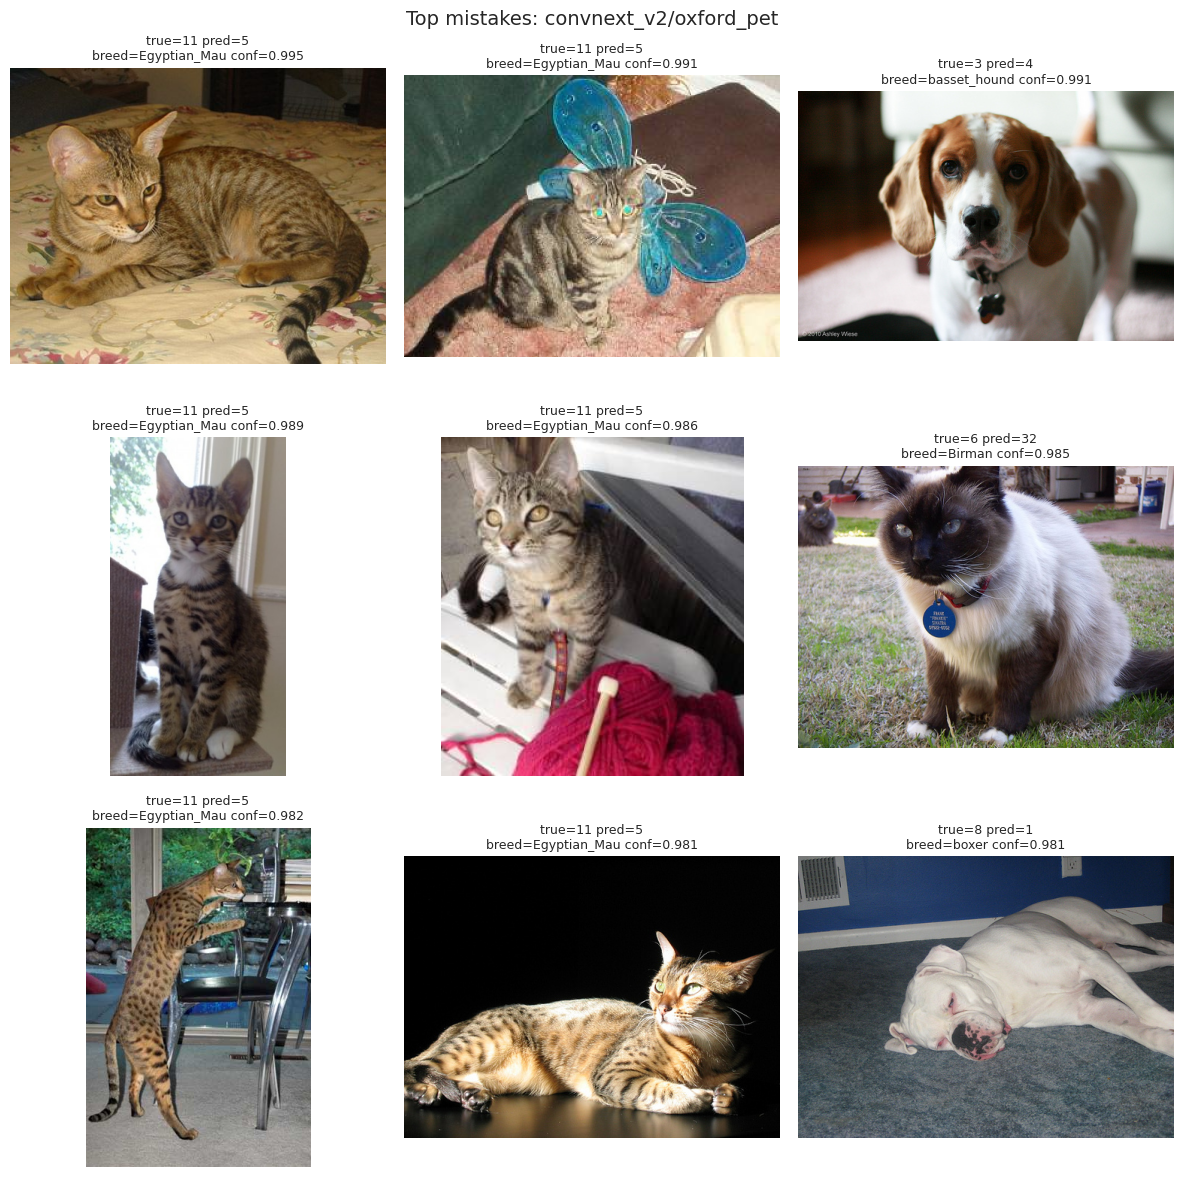

In [289]:
num_examples = min(9, len(mistakes_df))
sample_mistakes_df = mistakes_df.head(num_examples)

if num_examples == 0:
    print("誤分類が見つかりません。")
else:
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for ax in axes.flat:
        ax.axis("off")

    for ax, (_, row) in zip(axes.flat, sample_mistakes_df.iterrows()):
        image = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(image)
        title = (
            f"true={row['label']} pred={row['prediction']}\n"
            f"breed={row['breed_name']}"
        )
        if "confidence" in row.index and pd.notna(row["confidence"]):
            title += f" conf={row['confidence']:.3f}"
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    plt.suptitle(f"Top mistakes: {selected_model_experiment}", fontsize=14)
    plt.tight_layout()
    plt.show()


## 8. 見るべきポイント

この notebook の見方は次です。

- 全実験共通: `validation / test accuracy`
- tuning 実験だけ: `grid / optuna` の改善推移
- 学習あり実験だけ: 学習曲線
- predictions がある実験: クラス別成績と誤分類
- confidence の意味が揃う実験だけ: confidence 分布

つまり、比較軸ごとに対象を変えるのが前提です。無理に全部を同じ軸へ押し込みません。
